# Study 1

Step 1: Data Loading & Verification

In [2]:
import pandas as pd
import os

# --- CONFIGURATION ---
# Use the path exactly as you showed (forward slashes work best in Python)
BASE_PATH = "E:/Fall 25/Machine Learning/Assignments/HW4/ML_HW_4/Data/"
LABEL_FILE = "DepressionLabels.csv"
ACOUSTICS_FOLDER = "EDAIC Acoustics"

# 1. Load Labels
label_path = os.path.join(BASE_PATH, LABEL_FILE)
try:
    labels_df = pd.read_csv(label_path)
    print(f"SUCCESS: Loaded Labels file. Found {len(labels_df)} entries.")
except FileNotFoundError:
    print(f"ERROR: Could not find labels at {label_path}")

# 2. Check the 'EDAIC Acoustics' folder content
acoustics_path = os.path.join(BASE_PATH, ACOUSTICS_FOLDER)

if os.path.exists(acoustics_path):
    files = os.listdir(acoustics_path)
    csv_files = [f for f in files if f.endswith('.csv')]
    
    print(f"\nChecking folder: {acoustics_path}")
    print(f"Found {len(csv_files)} CSV files.")
    
    if len(csv_files) > 0:
        print("First 3 files found:")
        for f in csv_files[:3]:
            print(f" - {f}")
            
        # Quick check: Do these files match the Participant IDs?
        # Let's take the first file and see if we can extract an ID
        sample_file = csv_files[0]
        try:
            # Assuming file starts with ID (e.g., "300_utterance_agg.csv" or "300_something.csv")
            extracted_id = int(sample_file.split('_')[0])
            print(f"\nSample ID extracted from '{sample_file}': {extracted_id}")
            
            # Check if this ID is in our labels
            if extracted_id in labels_df['Participant_ID'].values:
                print("MATCH: This ID exists in the labels file.")
            else:
                print("WARNING: This ID is NOT in the labels file.")
                
        except ValueError:
            print(f"\nWARNING: Could not extract a numeric ID from filename '{sample_file}'")
    else:
        print("WARNING: No CSV files found in the Acoustics folder.")
else:
    print(f"ERROR: Could not find folder at {acoustics_path}")

SUCCESS: Loaded Labels file. Found 219 entries.

Checking folder: E:/Fall 25/Machine Learning/Assignments/HW4/ML_HW_4/Data/EDAIC Acoustics
Found 190 CSV files.
First 3 files found:
 - 386_utterance_agg.csv
 - 387_utterance_agg.csv
 - 388_utterance_agg.csv

Sample ID extracted from '386_utterance_agg.csv': 386
MATCH: This ID exists in the labels file.


### Step (a): Extracting Language Features

In [3]:
import pandas as pd
import numpy as np
import os
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

# --- CONFIGURATION ---
BASE_PATH = "E:/Fall 25/Machine Learning/Assignments/HW4/ML_HW_4/Data/"
LABEL_FILE = "DepressionLabels.csv"
ACOUSTICS_FOLDER = "EDAIC Acoustics"

# --- SETUP VADER SENTIMENT ---
# Download the VADER lexicon if not already present
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    print("Downloading VADER lexicon...")
    nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

# --- 1. PREPARE LISTS ---
participant_ids = []
transcripts = []       # For TF-IDF
sentiment_means = []   # For Semantic Feature
y_scores = []          # Target (PHQ Score)

# Load labels again to be safe
label_path = os.path.join(BASE_PATH, LABEL_FILE)
labels_df = pd.read_csv(label_path).set_index('Participant_ID')

# --- 2. MAIN LOOP ---
print("Starting Feature Extraction...")
acoustics_path = os.path.join(BASE_PATH, ACOUSTICS_FOLDER)
files = [f for f in os.listdir(acoustics_path) if f.endswith('.csv')]

count = 0
for filename in files:
    try:
        # Extract ID (e.g., 386 from 386_utterance_agg.csv)
        pid = int(filename.split('_')[0])
        
        # Check if we have a label for this ID
        if pid in labels_df.index:
            # Read the file
            df_part = pd.read_csv(os.path.join(acoustics_path, filename))
            
            # -- A. Text Processing --
            # Force text column to string to handle any missing/NaN values
            text_series = df_part['Text'].astype(str)
            
            # Join all sentences into one block of text (for TF-IDF later)
            full_transcript = " ".join(text_series.tolist())
            
            # -- B. Sentiment Processing (VADER) --
            # Calculate compound score for every utterance
            # We filter out empty strings to avoid skewing the average
            compound_scores = [analyzer.polarity_scores(t)['compound'] for t in text_series if len(t.strip()) > 0]
            
            if compound_scores:
                avg_sentiment = np.mean(compound_scores)
            else:
                avg_sentiment = 0.0
            
            # -- Store Data --
            participant_ids.append(pid)
            transcripts.append(full_transcript)
            sentiment_means.append(avg_sentiment)
            y_scores.append(labels_df.loc[pid, 'PHQ_Score'])
            
            count += 1
            if count % 20 == 0:
                print(f"Processed {count} participants...")

    except Exception as e:
        print(f"Error processing file {filename}: {e}")

# --- 3. VECTORIZATION (TF-IDF) ---
print(f"Finished processing {len(participant_ids)} participants.")
print("Vectorizing text (TF-IDF)...")

# Limit max_features to keep the dataset manageable (e.g., top 1000 words)
# You can adjust 'max_features' later if you want more complexity
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = tfidf.fit_transform(transcripts).toarray()

# --- 4. CREATE FINAL DATAFRAME FOR PART (A) ---
# Create a DataFrame with the TF-IDF features
tfidf_cols = [f"word_{i}" for i in range(X_tfidf.shape[1])]
df_features_text = pd.DataFrame(X_tfidf, columns=tfidf_cols, index=participant_ids)

# Add the Semantic Feature (VADER score)
df_features_text['VADER_Sentiment'] = sentiment_means

# Add the Target Label
df_features_text['PHQ_Score'] = y_scores

print("\nFeature Extraction Complete!")
print(f"Data Shape: {df_features_text.shape}")
print(df_features_text.head())

Starting Feature Extraction...
Processed 20 participants...
Processed 40 participants...
Processed 60 participants...
Processed 80 participants...
Processed 100 participants...
Processed 120 participants...
Finished processing 134 participants.
Vectorizing text (TF-IDF)...

Feature Extraction Complete!
Data Shape: (134, 1002)
       word_0    word_1  word_2  word_3  word_4  word_5  word_6    word_7  \
386  0.017545  0.000000     0.0     0.0     0.0     0.0     0.0  0.000000   
387  0.043717  0.000000     0.0     0.0     0.0     0.0     0.0  0.050464   
388  0.049338  0.000000     0.0     0.0     0.0     0.0     0.0  0.000000   
389  0.092189  0.089471     0.0     0.0     0.0     0.0     0.0  0.000000   
390  0.000000  0.000000     0.0     0.0     0.0     0.0     0.0  0.035288   

     word_8    word_9  ...  word_992  word_993  word_994  word_995  word_996  \
386     0.0  0.000000  ...  0.035183       0.0  0.021605  0.000000  0.000000   
387     0.0  0.000000  ...  0.116890       0.0  0

###  Step (b): Interpretable Models with Language Features

In [4]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# --- 1. SETUP ---
# Use the dataframe from the previous step
X = df_features_text.drop(columns=['PHQ_Score']).values
y = df_features_text['PHQ_Score'].values
feature_names = df_features_text.drop(columns=['PHQ_Score']).columns

# --- 2. DEFINE METRICS ---
def get_relative_error(y_true, y_pred):
    """
    Formula from PDF: |Estimated - Actual| / Max(PHQ-8)
    Max PHQ-8 score is 24.
    """
    # Clip predictions to be safe (no negative scores)
    y_pred = np.maximum(y_pred, 0)
    abs_diff = np.abs(y_pred - y_true)
    # Mean of the relative errors for the batch
    return np.mean(abs_diff / 24.0)

# --- 3. EXPERIMENT: VARYING TREE DEPTH ---
depths = [2, 4, 6, 10, None]  # 'None' means full depth (prone to overfitting)
results = []

print(f"{'Depth':<10} {'Pearson r':<15} {'Rel Error (RE)':<15}")
print("-" * 40)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in depths:
    r_scores = []
    re_scores = []
    
    # Cross Validation Loop
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train Model
        dt = DecisionTreeRegressor(max_depth=k, random_state=42)
        dt.fit(X_train, y_train)
        
        # Predict
        y_pred = dt.predict(X_test)
        
        # Calculate Metrics
        # Pearson returns (correlation, p-value), we just want correlation [0]
        # Handle cases where correlation is NaN (constant prediction)
        if np.std(y_pred) == 0:
            r = 0
        else:
            r = pearsonr(y_test, y_pred)[0]
            
        re = get_relative_error(y_test, y_pred)
        
        r_scores.append(r)
        re_scores.append(re)
    
    # Average across folds
    avg_r = np.mean(r_scores)
    avg_re = np.mean(re_scores)
    
    results.append((str(k), avg_r, avg_re))
    print(f"{str(k):<10} {avg_r:.4f}          {avg_re:.4f}")

# --- 4. INTERPRETABILITY (Feature Importance) ---
# Let's train one final tree with a reasonable depth (e.g., 4) to see top features
print("\n--- Feature Interpretation (Depth=4) ---")
final_model = DecisionTreeRegressor(max_depth=4, random_state=42)
final_model.fit(X, y)

importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 10 Most Important Features:")
for i in range(10):
    idx = indices[i]
    print(f"{i+1}. {feature_names[idx]} ({importances[idx]:.4f})")

# Visual check of prediction quality
y_final_pred = final_model.predict(X)
print(f"\nExample Prediction: Actual={y[0]}, Predicted={y_final_pred[0]:.2f}")

Depth      Pearson r       Rel Error (RE) 
----------------------------------------
2          0.0218          0.2254
4          -0.0652          0.2578
6          -0.0588          0.2553
10         -0.0601          0.2711
None       0.0193          0.2683

--- Feature Interpretation (Depth=4) ---
Top 10 Most Important Features:
1. word_573 (0.2186)
2. word_880 (0.1766)
3. word_349 (0.1409)
4. word_251 (0.1373)
5. word_793 (0.1299)
6. word_441 (0.1126)
7. word_953 (0.0283)
8. word_366 (0.0260)
9. word_711 (0.0122)
10. word_402 (0.0098)

Example Prediction: Actual=11, Predicted=3.87


In [5]:
# Get the mapping from index (e.g., 573) to word (e.g., "sad")
vocab = tfidf.get_feature_names_out()

print(f"Total vocabulary size: {len(vocab)}")
print("\n--- Corrected Feature Interpretation (Depth=4) ---")

# Re-print top 10 with actual names
for i in range(10):
    idx = indices[i]
    if idx < len(vocab):
        # It's a TF-IDF word
        print(f"{i+1}. {vocab[idx]} ({importances[idx]:.4f})")
    else:
        # It's the Sentiment Score (last column)
        print(f"{i+1}. VADER_Sentiment ({importances[idx]:.4f})")

Total vocabulary size: 1000

--- Corrected Feature Interpretation (Depth=4) ---
1. medication (0.2186)
2. therapy (0.1766)
3. forget (0.1409)
4. dog (0.1373)
5. sleep (0.1299)
6. hi (0.1126)
7. way (0.0283)
8. general (0.0260)
9. quite (0.0122)
10. guilty (0.0098)


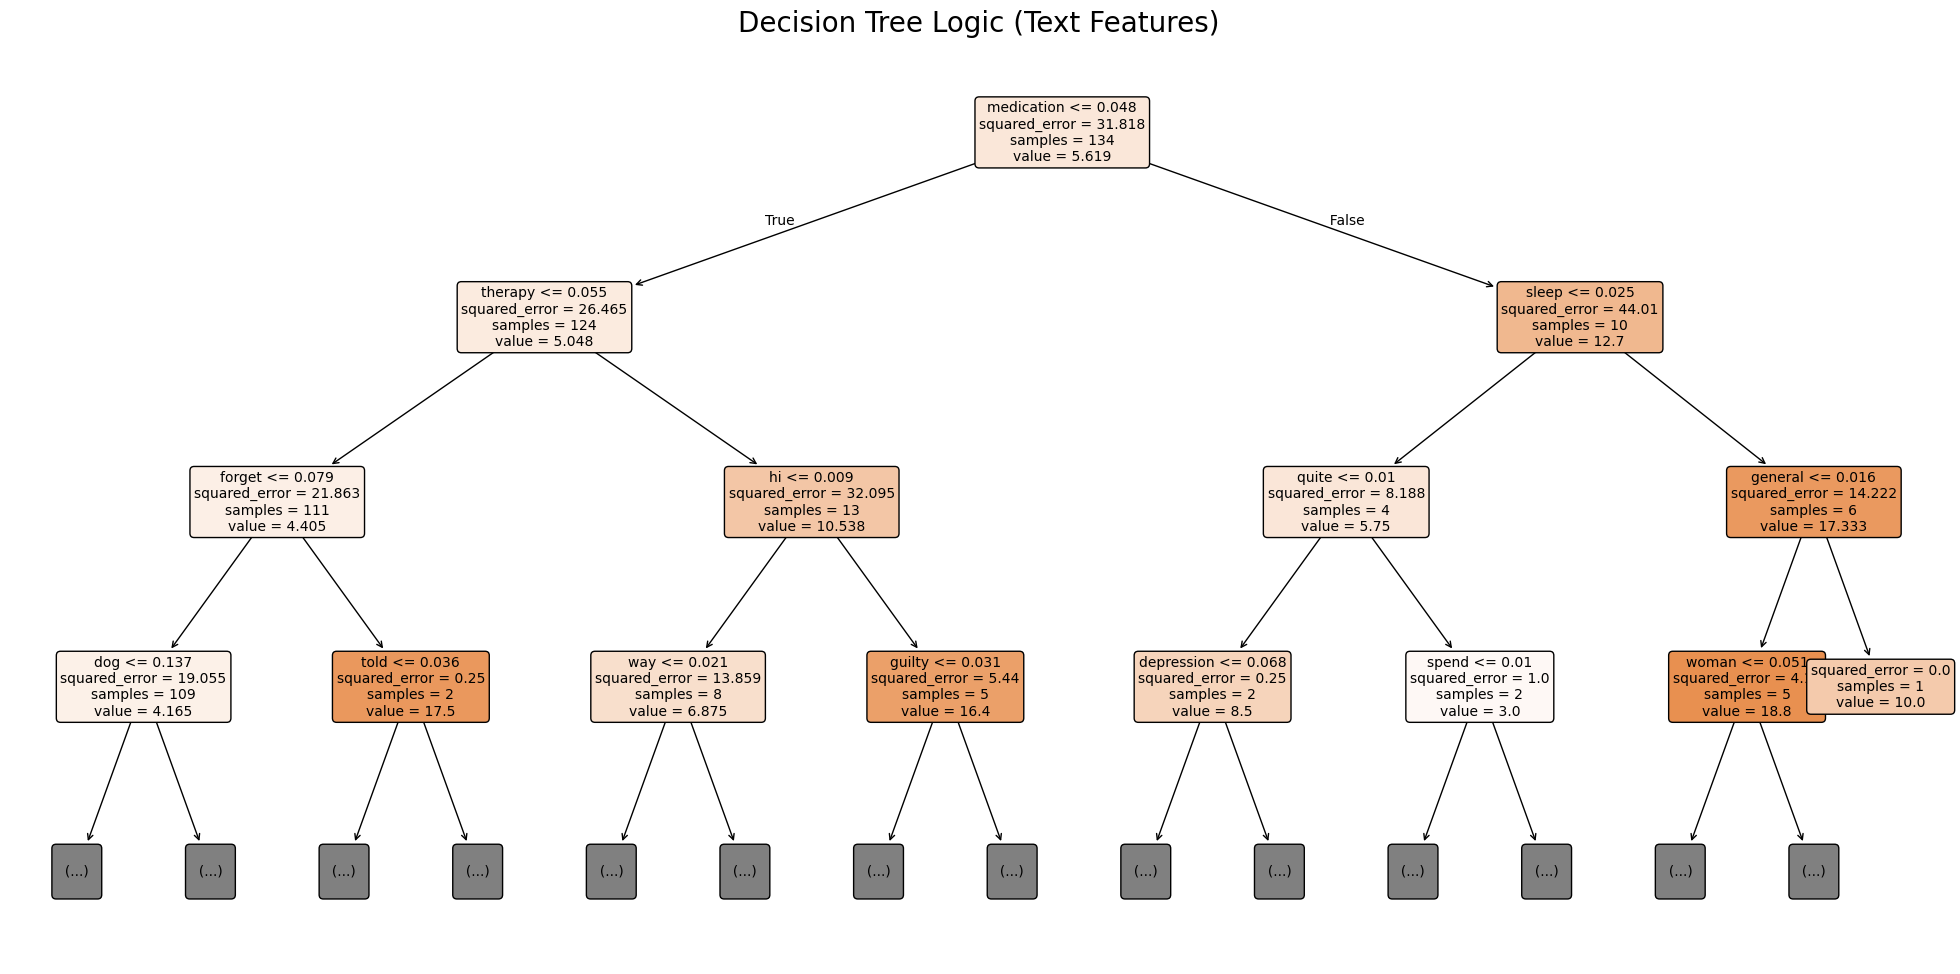

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# --- PREPARE FEATURE NAMES ---
# We need to combine TF-IDF words + VADER_Sentiment into one list
text_feature_names = list(tfidf.get_feature_names_out()) + ['VADER_Sentiment']

# --- PLOT THE TREE ---
plt.figure(figsize=(25, 12))  # Big figure for clarity

# We limit max_depth=3 so the plot is readable in a presentation
# (The actual tree might be deeper, but we only show the top logic)
plot_tree(final_model, 
          feature_names=text_feature_names, 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          max_depth=3) 

plt.title("Decision Tree Logic (Text Features)", fontsize=20)
plt.show()

### Step (c): Acoustic Features 

In [7]:
# --- PART C: ACOUSTIC FEATURE EXTRACTION & MODELING ---
print("Starting Acoustic Feature Extraction...")

X_audio = []
y_audio = []
audio_pids = [] # To keep track of IDs

# We need to reload the file list to be sure
acoustics_path = os.path.join(BASE_PATH, ACOUSTICS_FOLDER)
files = [f for f in os.listdir(acoustics_path) if f.endswith('.csv')]

count = 0
for filename in files:
    try:
        pid = int(filename.split('_')[0])
        
        # Only process if we have a label for this person
        if pid in labels_df.index:
            # Read file
            df_part = pd.read_csv(os.path.join(acoustics_path, filename))
            
            # 1. Identify Acoustic Columns
            # The assignment mentions eGeMAPS features. 
            # In these files, they usually contain 'sma' (Simple Moving Average).
            acoustic_cols = [c for c in df_part.columns if 'sma' in c]
            
            if not acoustic_cols:
                print(f"Warning: No acoustic columns found for {pid}")
                continue

            # 2. Aggregate (Mean, Std, Min, Max)
            # This turns the whole session into one row of statistics
            stats = df_part[acoustic_cols].agg(['mean', 'std', 'min', 'max'])
            
            # Flatten to 1D vector: [Feat1_mean, Feat1_std, ..., FeatN_max]
            flat_feats = stats.unstack().values
            
            # Handle potential NaNs (e.g. if a file has only 1 line, std is NaN)
            flat_feats = np.nan_to_num(flat_feats)
            
            X_audio.append(flat_feats)
            y_audio.append(labels_df.loc[pid, 'PHQ_Score'])
            audio_pids.append(pid)
            
            count += 1
            if count % 20 == 0:
                print(f"Processed audio for {count} participants...")

    except Exception as e:
        print(f"Error on {filename}: {e}")

X_audio = np.array(X_audio)
y_audio = np.array(y_audio)

print(f"\nFinal Acoustic Data Shape: {X_audio.shape}")

# --- 3. GENERATE FEATURE NAMES ---
# We need these to interpret the results later.
# We take the columns from the last processed dataframe
base_names = acoustic_cols
feat_names_audio = []
# The order of unstack() is: Column1_mean, Column1_std, ... Column2_mean, etc.
for col in base_names:
    for stat in ['mean', 'std', 'min', 'max']:
        feat_names_audio.append(f"{col}_{stat}")

# --- 4. DECISION TREE EXPERIMENT ---
print("\n--- Acoustic Decision Tree Results ---")
print(f"{'Depth':<10} {'Pearson r':<15} {'Rel Error (RE)':<15}")
print("-" * 40)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_depth = None
best_r = -1

for k in [2, 4, 6, 10, None]:
    r_scores = []
    re_scores = []
    
    for train_idx, test_idx in kf.split(X_audio):
        X_tr, X_te = X_audio[train_idx], X_audio[test_idx]
        y_tr, y_te = y_audio[train_idx], y_audio[test_idx]
        
        dt = DecisionTreeRegressor(max_depth=k, random_state=42)
        dt.fit(X_tr, y_tr)
        y_pred = dt.predict(X_te)
        
        # Calculate Pearson r
        if np.std(y_pred) == 0:
            r = 0 # Avoid crash if model predicts constant value
        else:
            r = pearsonr(y_te, y_pred)[0]
            
        re = get_relative_error(y_te, y_pred)
        
        r_scores.append(r)
        re_scores.append(re)
    
    avg_r = np.mean(r_scores)
    print(f"{str(k):<10} {avg_r:.4f}          {np.mean(re_scores):.4f}")
    
    if avg_r > best_r:
        best_r = avg_r
        best_depth = k

# --- 5. INTERPRETABILITY ---
print(f"\n--- Top Acoustic Features (Using Best Depth: {best_depth}) ---")
if best_depth is None: best_depth = 4 # Default if None was best or negative

final_dt_audio = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
final_dt_audio.fit(X_audio, y_audio)
importances = final_dt_audio.feature_importances_
indices = np.argsort(importances)[::-1]

for i in range(10):
    idx = indices[i]
    print(f"{i+1}. {feat_names_audio[idx]} ({importances[idx]:.4f})")

Starting Acoustic Feature Extraction...
Processed audio for 20 participants...
Processed audio for 40 participants...
Processed audio for 60 participants...
Processed audio for 80 participants...
Processed audio for 100 participants...
Processed audio for 120 participants...

Final Acoustic Data Shape: (134, 92)

--- Acoustic Decision Tree Results ---
Depth      Pearson r       Rel Error (RE) 
----------------------------------------
2          -0.0252          0.2268
4          0.0316          0.2433
6          0.0367          0.2502
10         0.0292          0.2588
None       0.0058          0.2684

--- Top Acoustic Features (Using Best Depth: 6) ---
1. mfcc2_sma3_max (0.1236)
2. F1amplitudeLogRelF0_sma3nz_mean (0.0927)
3. shimmerLocaldB_sma3nz_std (0.0859)
4. shimmerLocaldB_sma3nz_mean (0.0814)
5. spectralFlux_sma3_min (0.0795)
6. logRelF0-H1-H2_sma3nz_mean (0.0777)
7. hammarbergIndex_sma3_std (0.0674)
8. spectralFlux_sma3_mean (0.0616)
9. logRelF0-H1-A3_sma3nz_max (0.0604)
10. F0s

C:\Users\agarw\AppData\Local\Temp\ipykernel_6204\3416317898.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_names, palette='magma')


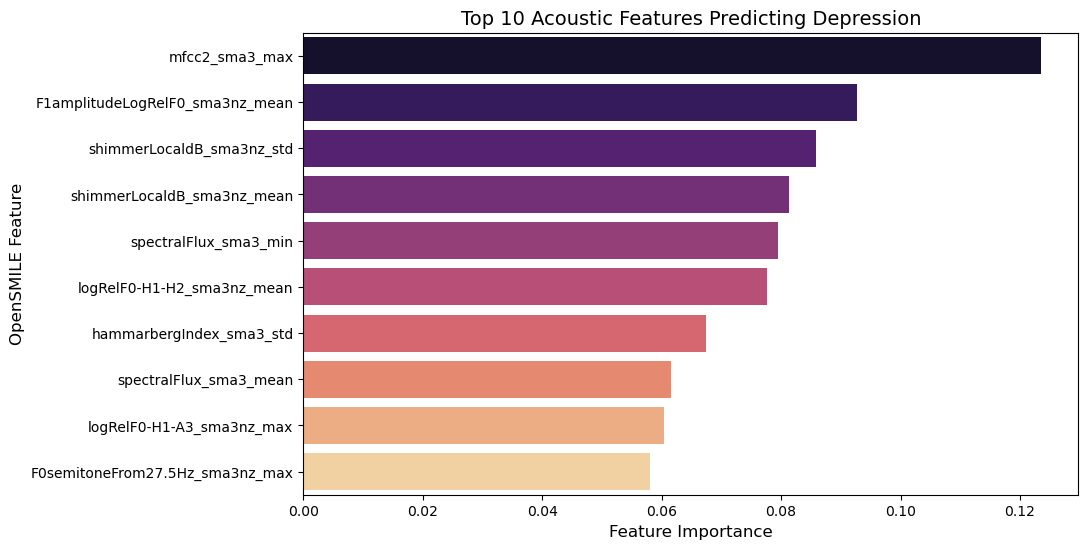

In [8]:
import seaborn as sns

# Get top 10 features from the Audio Decision Tree
importances = final_dt_audio.feature_importances_
indices = np.argsort(importances)[::-1][:10]
top_names = [feat_names_audio[i] for i in indices]
top_values = importances[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_values, y=top_names, palette='magma')
plt.title('Top 10 Acoustic Features Predicting Depression', fontsize=14)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('OpenSMILE Feature', fontsize=12)
plt.show()

### Step (d): Deep Learning Models 

In [9]:
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Count:       {torch.cuda.device_count()}")
    print(f"Current Device:  {torch.cuda.current_device()}")
    print(f"Device Name:     {torch.cuda.get_device_name(0)}")
else:
    print("\nWARNING: PyTorch is running on CPU.")
    print("You likely installed the CPU-only version of PyTorch.")

PyTorch Version: 2.6.0+cu124
CUDA Available:  True
GPU Count:       1
Current Device:  0
Device Name:     NVIDIA GeForce RTX 4070 Laptop GPU


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from scipy.stats import pearsonr

# --- 1. SETUP GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# --- 2. RELOAD & ROBUST PREPROCESS ---
BASE_PATH = "E:/Fall 25/Machine Learning/Assignments/HW4/ML_HW_4/Data/"
ACOUSTICS_FOLDER = "EDAIC Acoustics"
LABEL_FILE = "DepressionLabels.csv"
MAX_SEQ_LENGTH = 100
MAX_WORDS = 5000 

print("Loading Data...")
labels_df = pd.read_csv(os.path.join(BASE_PATH, LABEL_FILE)).set_index('Participant_ID')
acoustics_path = os.path.join(BASE_PATH, ACOUSTICS_FOLDER)
files = [f for f in os.listdir(acoustics_path) if f.endswith('.csv')]

raw_audio = []
raw_text = []
y_list = []

for filename in files:
    try:
        pid = int(filename.split('_')[0])
        if pid in labels_df.index:
            df = pd.read_csv(os.path.join(acoustics_path, filename))
            cols = [c for c in df.columns if 'sma' in c]
            raw_audio.append(df[cols].values)
            raw_text.append(" ".join(df['Text'].astype(str).tolist()))
            y_list.append(labels_df.loc[pid, 'PHQ_Score'])
    except: pass

y_dl = np.array(y_list, dtype=np.float32)

# Safety Fix 1: Check for NaN in raw audio and fill with 0
all_audio = np.vstack(raw_audio)
all_audio = np.nan_to_num(all_audio) # Fix raw NaNs

# Safety Fix 2: Handle division by zero in Scaler
scaler = StandardScaler()
scaler.fit(all_audio)
# If a column has 0 variance, scale is 0. Avoid division by zero issues.
scaler.scale_ = np.where(scaler.scale_ == 0, 1, scaler.scale_) 

norm_audio = [scaler.transform(np.nan_to_num(x)) for x in raw_audio]
X_audio = pad_sequences(norm_audio, maxlen=MAX_SEQ_LENGTH, dtype='float32', padding='post', truncating='post')

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(raw_text)
X_text = pad_sequences(tokenizer.texts_to_sequences(raw_text), maxlen=MAX_SEQ_LENGTH*10, padding='post', truncating='post')

X_audio_torch = torch.tensor(X_audio, dtype=torch.float32)
X_text_torch = torch.tensor(X_text, dtype=torch.long)
y_torch = torch.tensor(y_dl, dtype=torch.float32).view(-1, 1)

print(f"Data Ready (Sanitized). Audio: {X_audio_torch.shape}")

# --- 3. DEFINE MODELS ---
class AudioLSTM(nn.Module):
    def __init__(self, input_dim):
        super(AudioLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, 16, batch_first=True)
        self.fc1 = nn.Linear(16, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        
    def forward(self, x):
        _, (hn, _) = self.lstm(x) 
        x = hn[-1] 
        x = self.relu(self.fc1(x))
        return self.fc2(x)

class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=50):
        super(TextLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, 16, batch_first=True)
        self.fc1 = nn.Linear(16, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hn, _) = self.lstm(x)
        x = hn[-1]
        x = self.relu(self.fc1(x))
        return self.fc2(x)

class MultimodalLSTM(nn.Module):
    def __init__(self, audio_dim, vocab_size, embed_dim=50):
        super(MultimodalLSTM, self).__init__()
        self.lstm_a = nn.LSTM(audio_dim, 16, batch_first=True)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm_t = nn.LSTM(embed_dim, 16, batch_first=True)
        self.fc1 = nn.Linear(16 + 16, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x_a, x_t):
        _, (hn_a, _) = self.lstm_a(x_a)
        emb = self.embedding(x_t)
        _, (hn_t, _) = self.lstm_t(emb)
        combined = torch.cat((hn_a[-1], hn_t[-1]), dim=1)
        x = self.relu(self.fc1(combined))
        return self.fc2(x)

# --- 4. TRAINING LOOP (With Clipping) ---
def train_model(model, train_loader, epochs=20):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(epochs):
        for batch in train_loader:
            optimizer.zero_grad()
            if len(batch) == 2:
                X_b, y_b = batch
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
            else:
                Xa_b, Xt_b, y_b = batch
                Xa_b, Xt_b, y_b = Xa_b.to(device), Xt_b.to(device), y_b.to(device)
                preds = model(Xa_b, Xt_b)
            
            loss = criterion(preds, y_b)
            loss.backward()
            
            # CRITICAL FIX: Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
    return model

def evaluate_model(model, X_data, y_data, is_multi=False):
    model.eval()
    with torch.no_grad():
        if not is_multi:
            preds = model(X_data.to(device)).cpu().numpy().flatten()
        else:
            preds = model(X_data[0].to(device), X_data[1].to(device)).cpu().numpy().flatten()
    return preds

# --- 5. EXECUTE ---
print("Starting Robust Training...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {'Audio': [], 'Text': [], 'Multimodal': []}

fold = 1
for train_idx, test_idx in kf.split(X_audio_torch):
    print(f"Fold {fold}...", end=" ")
    
    # Loaders
    train_ds_a = TensorDataset(X_audio_torch[train_idx], y_torch[train_idx])
    train_dl_a = DataLoader(train_ds_a, batch_size=16, shuffle=True)
    
    train_ds_t = TensorDataset(X_text_torch[train_idx], y_torch[train_idx])
    train_dl_t = DataLoader(train_ds_t, batch_size=16, shuffle=True)
    
    train_ds_m = TensorDataset(X_audio_torch[train_idx], X_text_torch[train_idx], y_torch[train_idx])
    train_dl_m = DataLoader(train_ds_m, batch_size=16, shuffle=True)
    
    # Train
    m_a = AudioLSTM(input_dim=X_audio_torch.shape[2]).to(device)
    train_model(m_a, train_dl_a)
    p_a = evaluate_model(m_a, X_audio_torch[test_idx], y_torch[test_idx])
    
    m_t = TextLSTM(vocab_size=MAX_WORDS).to(device)
    train_model(m_t, train_dl_t)
    p_t = evaluate_model(m_t, X_text_torch[test_idx], y_torch[test_idx])
    
    m_m = MultimodalLSTM(audio_dim=X_audio_torch.shape[2], vocab_size=MAX_WORDS).to(device)
    train_model(m_m, train_dl_m)
    p_m = evaluate_model(m_m, (X_audio_torch[test_idx], X_text_torch[test_idx]), y_torch[test_idx], is_multi=True)
    
    # Metrics
    y_true = y_dl[test_idx]
    for name, pred in [('Audio', p_a), ('Text', p_t), ('Multimodal', p_m)]:
        # Final safety check for nan in prediction
        if np.isnan(pred).any(): pred = np.nan_to_num(pred, nan=np.mean(y_true))
        
        if np.std(pred) < 1e-5: r = 0.0
        else: r = pearsonr(y_true, pred)[0]
        re = np.mean(np.abs(pred - y_true) / 24.0)
        results[name].append((r, re))
        
    print("Done.")
    fold += 1

print("\n" + "="*50)
print(f"{'Model Type':<15} {'Avg Pearson r':<15} {'Avg Rel Error':<15}")
print("-" * 50)
for name in ['Audio', 'Text', 'Multimodal']:
    metrics = results[name]
    avg_r = np.mean([m[0] for m in metrics])
    avg_re = np.mean([m[1] for m in metrics])
    print(f"{name:<15} {avg_r:.4f}          {avg_re:.4f}")
print("="*50)

Running on: NVIDIA GeForce RTX 4070 Laptop GPU
Loading Data...
Data Ready (Sanitized). Audio: torch.Size([134, 100, 23])
Starting Robust Training...
Fold 1... Done.
Fold 2... Done.
Fold 3... Done.
Fold 4... Done.
Fold 5... Done.

Model Type      Avg Pearson r   Avg Rel Error  
--------------------------------------------------
Audio           -0.2186          0.1929
Text            -0.0322          0.1909
Multimodal      -0.0915          0.1989


### Step (e): Explainable ML (SHAP) 

c:\Users\agarw\.conda\envs\ml-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- Starting Part (e) SHAP Explanation (PyTorch - Memory Safe) ---
Calculating SHAP values (Batched on GPU)...


100%|██████████| 5/5 [00:47<00:00,  9.52s/it]


Generating Summary Plot...


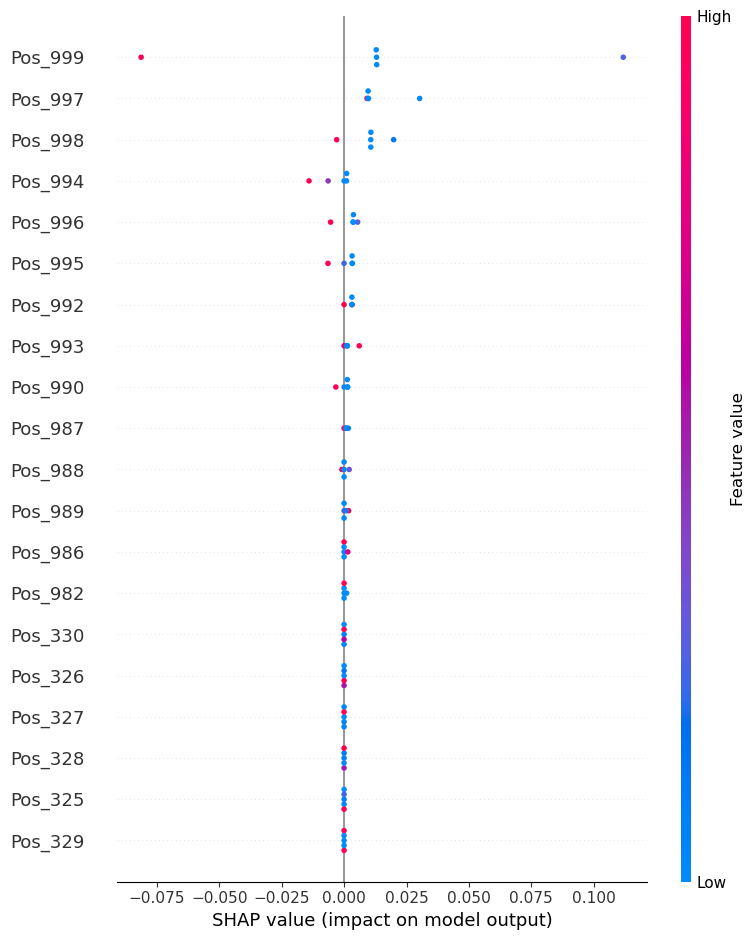


Decoding top features for Participant #0:
Position   Word            Impact
---------------------------------------------
999        say             0.1118
994        only            -0.0140
997        oh              0.0092
996        getting         -0.0054
992        and             0.0031


In [13]:
import shap
import numpy as np
import torch

print("\n--- Starting Part (e) SHAP Explanation (PyTorch - Memory Safe) ---")

# 1. Setup Data
# Use background data from the text tensor
background_indices = np.random.choice(len(X_text), 50, replace=False)
background_data = X_text[background_indices]
test_samples = X_text[:5]

# 2. Define Wrapper Function with BATCHING
def pytorch_predictor(data):
    # 'data' is a numpy array of perturbed samples (could be thousands of rows)
    results = []
    BATCH_SIZE = 32  # Small batch size to fit in GPU memory
    
    m_t.eval()
    
    # Process in chunks
    for i in range(0, len(data), BATCH_SIZE):
        chunk = data[i:i+BATCH_SIZE]
        tensor_chunk = torch.tensor(chunk, dtype=torch.long).to(device)
        
        with torch.no_grad():
            preds = m_t(tensor_chunk)
        
        results.append(preds.cpu().numpy().flatten())
    
    return np.concatenate(results)

# 3. Initialize & Run Explainer
print("Calculating SHAP values (Batched on GPU)...")
explainer = shap.KernelExplainer(pytorch_predictor, background_data)

# This will show a progress bar
shap_values = explainer.shap_values(test_samples)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

# 4. Visualization
print("Generating Summary Plot...")
shap.summary_plot(shap_values, test_samples, feature_names=[f"Pos_{i}" for i in range(test_samples.shape[1])])

# 5. Decode Top Features
print("\nDecoding top features for Participant #0:")
reverse_word_map = dict(map(reversed, tokenizer.word_index.items()))
top_indices = np.argsort(np.abs(shap_values[0]))[-5:][::-1]

print(f"{'Position':<10} {'Word':<15} {'Impact'}")
print("-" * 45)
for idx in top_indices:
    word_id = test_samples[0][idx]
    word = reverse_word_map.get(word_id, "<PAD>")
    print(f"{idx:<10} {word:<15} {shap_values[0][idx]:.4f}")

### Step (f): 

In [14]:
import torch
import numpy as np
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
import sys

# --- 1. GPU SETUP ---
print("--- Part (f) Bonus: Transformer (BERT) on GPU ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device} ({torch.cuda.get_device_name(0)})")

# --- 2. LOAD MODEL ---
print("Loading DistilBERT...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')
model.to(device)
model.eval()

# --- 3. EXTRACT EMBEDDINGS ---
# We use 'raw_text' list from the previous Part (d) block
if 'raw_text' not in locals():
    print("Error: 'raw_text' variable missing. Please re-run the Data Loading block from Part (d).")
else:
    print(f"Extracting embeddings for {len(raw_text)} participants...")
    
    X_bert = []
    
    # Process loop
    for i, text in enumerate(raw_text):
        # Tokenize (Truncate to 512, BERT's max limit)
        inputs = tokenizer(text, return_tensors="pt", max_length=512, truncation=True, padding=True)
        
        # Move to GPU
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Inference
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Take [CLS] token (first token) as the sentence embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()
        X_bert.append(cls_embedding)
        
        # Progress bar
        if (i+1) % 20 == 0:
            sys.stdout.write(f"\rProcessed {i+1}...")
            sys.stdout.flush()

    X_bert = np.array(X_bert)
    y_target = np.array(y_dl) # Reuse y from Part d
    print(f"\nBERT Embeddings Shape: {X_bert.shape}")

    # --- 4. TRAIN REGRESSOR (Ridge) ---
    print("\n--- Transformer Results (Ridge Regression) ---")
    print(f"{'Fold':<10} {'Pearson r':<15} {'Rel Error':<15}")
    print("-" * 40)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    r_scores = []
    re_scores = []
    fold = 1

    for train_idx, test_idx in kf.split(X_bert):
        X_tr, X_te = X_bert[train_idx], X_bert[test_idx]
        y_tr, y_te = y_target[train_idx], y_target[test_idx]
        
        # Ridge Regression handles high-dimensional data (768 features) well
        clf = Ridge(alpha=10.0) 
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        
        # Metrics
        if np.std(y_pred) < 1e-5: r = 0.0
        else: r = pearsonr(y_te, y_pred)[0]
        
        # Clip negative predictions for reasonable error calc
        y_pred_safe = np.maximum(y_pred, 0)
        re = np.mean(np.abs(y_pred_safe - y_te) / 24.0)
        
        r_scores.append(r)
        re_scores.append(re)
        
        print(f"{fold:<10} {r:.4f}          {re:.4f}")
        fold += 1

    print("-" * 40)
    print(f"AVG       {np.mean(r_scores):.4f}          {np.mean(re_scores):.4f}")
    print("=" * 40)

--- Part (f) Bonus: Transformer (BERT) on GPU ---
Using Device: cuda (NVIDIA GeForce RTX 4070 Laptop GPU)
Loading DistilBERT...
Extracting embeddings for 134 participants...
Processed 120...
BERT Embeddings Shape: (134, 768)

--- Transformer Results (Ridge Regression) ---
Fold       Pearson r       Rel Error      
----------------------------------------
1          -0.1404          0.1825
2          -0.0467          0.1850
3          0.0053          0.2452
4          0.0209          0.1721
5          -0.2415          0.2556
----------------------------------------
AVG       -0.0805          0.2081


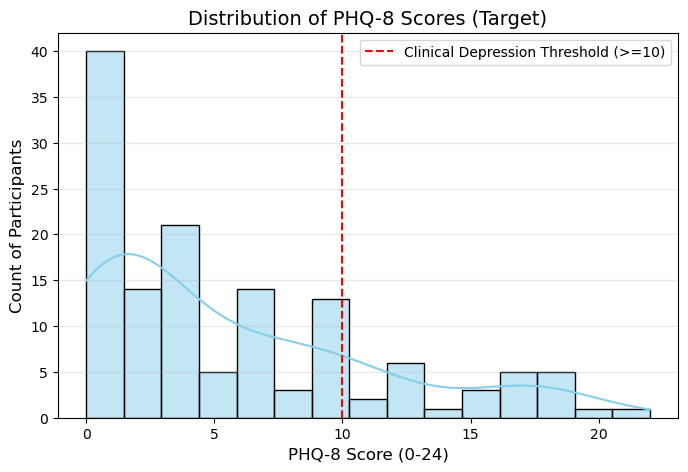

C:\Users\agarw\AppData\Local\Temp\ipykernel_6204\2660835118.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_names, palette='viridis')


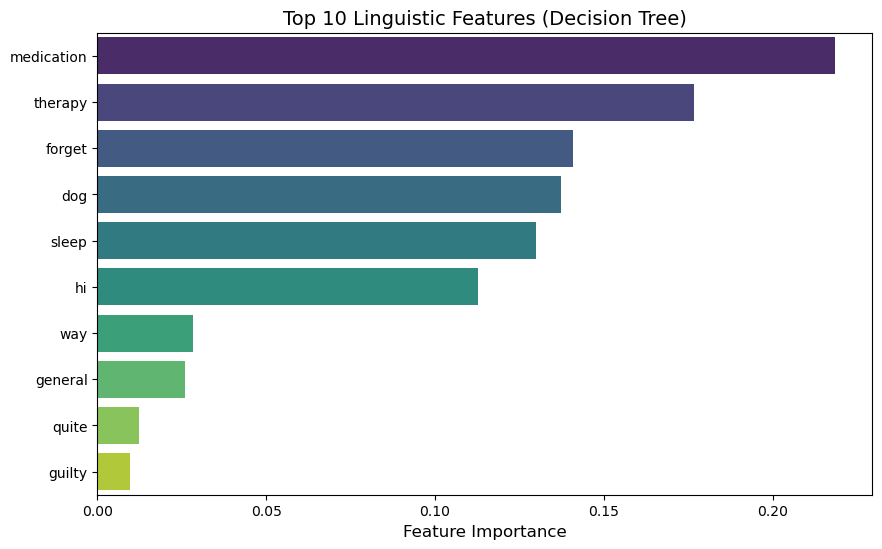

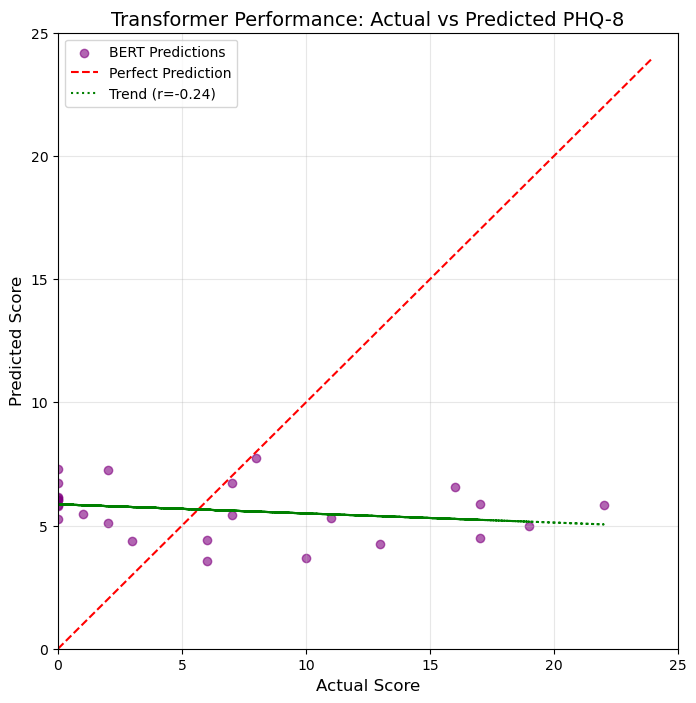

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# --- 1. DATASET DISTRIBUTION ---
plt.figure(figsize=(8, 5))
sns.histplot(y_dl, bins=15, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of PHQ-8 Scores (Target)', fontsize=14)
plt.xlabel('PHQ-8 Score (0-24)', fontsize=12)
plt.ylabel('Count of Participants', fontsize=12)
plt.axvline(x=10, color='red', linestyle='--', label='Clinical Depression Threshold (>=10)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- 2. FEATURE IMPORTANCE (TEXT DECISION TREE) ---
# We grab the importance from Part (b) 'final_model'
if 'final_model' in locals():
    importances = final_model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    
    # Map indices to words
    vocab = tfidf.get_feature_names_out()
    top_names = []
    for i in indices:
        if i < len(vocab):
            top_names.append(vocab[i])
        else:
            top_names.append("VADER_Sentiment")
            
    top_values = importances[indices]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_values, y=top_names, palette='viridis')
    plt.title('Top 10 Linguistic Features (Decision Tree)', fontsize=14)
    plt.xlabel('Feature Importance', fontsize=12)
    plt.show()

# --- 3. PREDICTION SCATTER PLOT (BERT MODEL) ---
# We visualize the predictions from the last fold of the BERT model (Part f)
# Assumes 'y_te' (Actual) and 'y_pred' (Predicted) from the last loop iteration exist
if 'y_te' in locals() and 'y_pred' in locals():
    plt.figure(figsize=(8, 8))
    plt.scatter(y_te, y_pred, alpha=0.6, color='purple', label='BERT Predictions')
    
    # Perfect prediction line
    plt.plot([0, 24], [0, 24], color='red', linestyle='--', label='Perfect Prediction')
    
    # Trend line
    m, b = np.polyfit(y_te, y_pred, 1)
    plt.plot(y_te, m*y_te + b, color='green', linestyle=':', label=f'Trend (r={pearsonr(y_te, y_pred)[0]:.2f})')

    plt.title('Transformer Performance: Actual vs Predicted PHQ-8', fontsize=14)
    plt.xlabel('Actual Score', fontsize=12)
    plt.ylabel('Predicted Score', fontsize=12)
    plt.xlim(0, 25)
    plt.ylim(0, 25)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()